In [1]:
# ================================================================
# TraceFinder Image Feature Extraction & Classification Pipeline
# ================================================================
# This notebook performs:
#   1. Image preprocessing & feature extraction
#   2. Dataset building from folder hierarchy
#   3. Visualization of scanner differences
#   4. Model training (Random Forest + SVM)
#   5. Model saving & prediction helper
# ================================================================

import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.filters import sobel
from scipy.stats import skew, kurtosis, entropy
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
from pathlib import Path
import time

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


In [2]:
def load_gray(img_path: str, size=(512, 512)) -> np.ndarray:
    """
    Load image as grayscale and resize to a consistent shape.
    Converts to float [0,1] range.
    """
    img = io.imread(img_path, as_gray=True)
    img = img_as_float(img)
    return cv2.resize(img, size, interpolation=cv2.INTER_AREA)

print("📷 Image loading function ready.")


📷 Image loading function ready.


In [3]:
def extract_features(img: np.ndarray, file_path: str, scanner_id: str = "unknown") -> dict:
    """
    Extract statistical + edge-based features from a grayscale image.
    Returns a dictionary of features for one image.
    """
    h, w = img.shape
    pixels = img.flatten()

    # Statistical metrics
    mean_intensity = np.mean(pixels)
    std_intensity = np.std(pixels)
    skewness = skew(pixels)
    kurt = kurtosis(pixels)
    hist = np.histogram(pixels, bins=256, range=(0, 1))[0] + 1e-6
    ent = entropy(hist)

    # Edge density via Sobel filter
    edges = sobel(img)
    edge_density = np.mean(edges > 0.1)

    return {
        "file_name": os.path.basename(file_path),
        "class_label": scanner_id,
        "width": w,
        "height": h,
        "aspect_ratio": w / h,
        "file_size_kb": os.path.getsize(file_path) / 1024,
        "mean_intensity": mean_intensity,
        "std_intensity": std_intensity,
        "skewness": skewness,
        "kurtosis": kurt,
        "entropy": ent,
        "edge_density": edge_density
    }

print("🧠 Feature extraction function ready.")


🧠 Feature extraction function ready.


In [4]:
def process_dataset_root(root_path: str, known_scanners=None, 
                         exts=('.tif', '.tiff', '.jpg', '.jpeg', '.png'),
                         batch_size=100, save_csv=True, csv_name='dataset_features.csv', 
                         verbose=True) -> pd.DataFrame:
    """
    Recursively process images from dataset root and extract features for each.
    Handles different folder naming and scanner identification patterns.
    """

    root = Path(root_path).resolve()
    if not root.exists():
        raise FileNotFoundError(f"Root path not found: {root}")

    # Normalize scanner names
    scanner_map = {k.lower(): v for k, v in (known_scanners or {}).items()}

    def infer_scanner_id(filepath: str) -> str:
        """Infer scanner name from folder hierarchy."""
        p = Path(filepath).resolve()
        cur = p.parent
        while cur != root and cur.parent != cur:
            lname = cur.name.lower()
            for pat, val in scanner_map.items():
                if pat in lname:
                    return val
            cur = cur.parent
        try:
            return p.relative_to(root).parts[0]
        except Exception:
            return p.parent.name

    # Collect image files
    files = [os.path.join(dp, f) for dp, _, fn in os.walk(root)
             for f in fn if f.lower().endswith(exts)]
    if verbose:
        print(f"📂 Found {len(files)} files under {root}")
    if not files:
        raise ValueError("No image files found in the given root directory!")

    all_features = []
    start_time = time.time()

    # Process all images
    for i, fpath in enumerate(files, start=1):
        try:
            scanner_id = infer_scanner_id(fpath)
            img = load_gray(fpath)
            feats = extract_features(img, fpath, scanner_id)
            all_features.append(feats)
        except Exception as e:
            print(f"⚠️ Error processing {fpath}: {e}")

        if verbose and (i % batch_size == 0 or i == len(files)):
            print(f"Processed {i}/{len(files)} files in {time.time() - start_time:.1f}s")

    metadata = pd.DataFrame(all_features)

    # Save features CSV
    if save_csv:
        out_csv = root / csv_name
        metadata.to_csv(out_csv, index=False)
        if verbose:
            print(f"✅ Saved metadata CSV -> {out_csv}")

    return metadata

print("🗂️ Dataset processing function ready.")


🗂️ Dataset processing function ready.


In [5]:
def visualize_feature_distributions(metadata: pd.DataFrame):
    """Visualize key feature distributions by scanner type."""
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    sns.boxplot(data=metadata, x='class_label', y='mean_intensity')
    plt.title('Mean Intensity by Scanner')
    plt.xticks(rotation=45)

    plt.subplot(2, 2, 2)
    sns.boxplot(data=metadata, x='class_label', y='edge_density')
    plt.title('Edge Density by Scanner')
    plt.xticks(rotation=45)

    plt.subplot(2, 2, 3)
    sns.boxplot(data=metadata, x='class_label', y='file_size_kb')
    plt.title('File Size by Scanner')
    plt.xticks(rotation=45)

    plt.subplot(2, 2, 4)
    sns.scatterplot(data=metadata, x='mean_intensity', y='edge_density', hue='class_label', alpha=0.7)
    plt.title('Edge Density vs Mean Intensity')
    plt.tight_layout()
    plt.show()

print("📊 Visualization function ready.")


📊 Visualization function ready.


In [6]:
def train_models(metadata: pd.DataFrame):
    """Train and evaluate RandomForest & SVM classifiers on extracted features."""

    if metadata.empty or 'class_label' not in metadata:
        raise ValueError("❌ Metadata missing or has no class_label column!")

    feature_cols = [c for c in metadata.columns if c not in ('file_name', 'class_label')]
    X = metadata[feature_cols].astype(float)
    y = metadata['class_label'].astype(str)

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # Ensure multiple classes
    unique, counts = np.unique(y_enc, return_counts=True)
    if len(unique) < 2:
        raise ValueError("❌ Only one class found — cannot train classifiers.")

    print("Class distribution:")
    for lbl, cnt in zip(le.classes_, counts):
        print(f" - {lbl}: {cnt} samples")

    stratify = y_enc if counts.min() >= 2 else None
    X_train, X_val, y_train, y_val = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=stratify
    )

    # Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_val)
    rf_acc = accuracy_score(y_val, rf_pred)
    print(f"\n🌲 RandomForest accuracy: {rf_acc:.4f}")

    # SVM (scaled)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    svm = SVC(kernel='rbf', C=1.0, probability=False, random_state=42)
    svm.fit(X_train_s, y_train)
    svm_pred = svm.predict(X_val_s)
    svm_acc = accuracy_score(y_val, svm_pred)
    print(f"⚙️ SVM accuracy: {svm_acc:.4f}")

    # Save models
    os.makedirs('models', exist_ok=True)
    joblib.dump({'model': rf, 'label_encoder': le, 'feature_cols': feature_cols}, 'models/rf_model.joblib')
    joblib.dump({'model': svm, 'scaler': scaler, 'label_encoder': le, 'feature_cols': feature_cols}, 'models/svm_model.joblib')

    print("\n✅ Models saved to ./models/")
    return rf, svm, le, scaler, feature_cols

print("🤖 Model training function ready.")


🤖 Model training function ready.


In [7]:
def predict_from_row(row: pd.Series, model, le: LabelEncoder, feature_cols, scaler=None) -> str:
    """
    Predict scanner label for a single row of features.
    Works for both Random Forest and SVM models.
    """
    Xr = pd.DataFrame([row])[feature_cols]
    if scaler is not None:
        Xr = scaler.transform(Xr)
    pred = model.predict(Xr)
    return le.inverse_transform(pred)[0]

print("🔮 Prediction helper ready.")


🔮 Prediction helper ready.


📂 Found 2200 files under E:\TraceFinder\Dataset
Processed 100/2200 files in 7.4s
Processed 200/2200 files in 24.3s
Processed 300/2200 files in 30.4s
Processed 400/2200 files in 46.9s
Processed 500/2200 files in 52.7s
Processed 600/2200 files in 69.5s
Processed 700/2200 files in 75.9s
Processed 800/2200 files in 92.6s
Processed 900/2200 files in 98.3s
Processed 1000/2200 files in 114.1s
Processed 1100/2200 files in 119.8s
Processed 1200/2200 files in 135.5s
Processed 1300/2200 files in 141.2s
Processed 1400/2200 files in 156.9s
Processed 1500/2200 files in 162.6s
Processed 1600/2200 files in 178.5s
Processed 1700/2200 files in 184.2s
Processed 1800/2200 files in 199.9s
Processed 1900/2200 files in 205.6s
Processed 2000/2200 files in 221.4s
Processed 2100/2200 files in 226.9s
Processed 2200/2200 files in 242.7s
✅ Saved metadata CSV -> E:\TraceFinder\Dataset\all_scanners_features.csv

✅ Extracted 2200 feature rows from E:/TraceFinder/Dataset


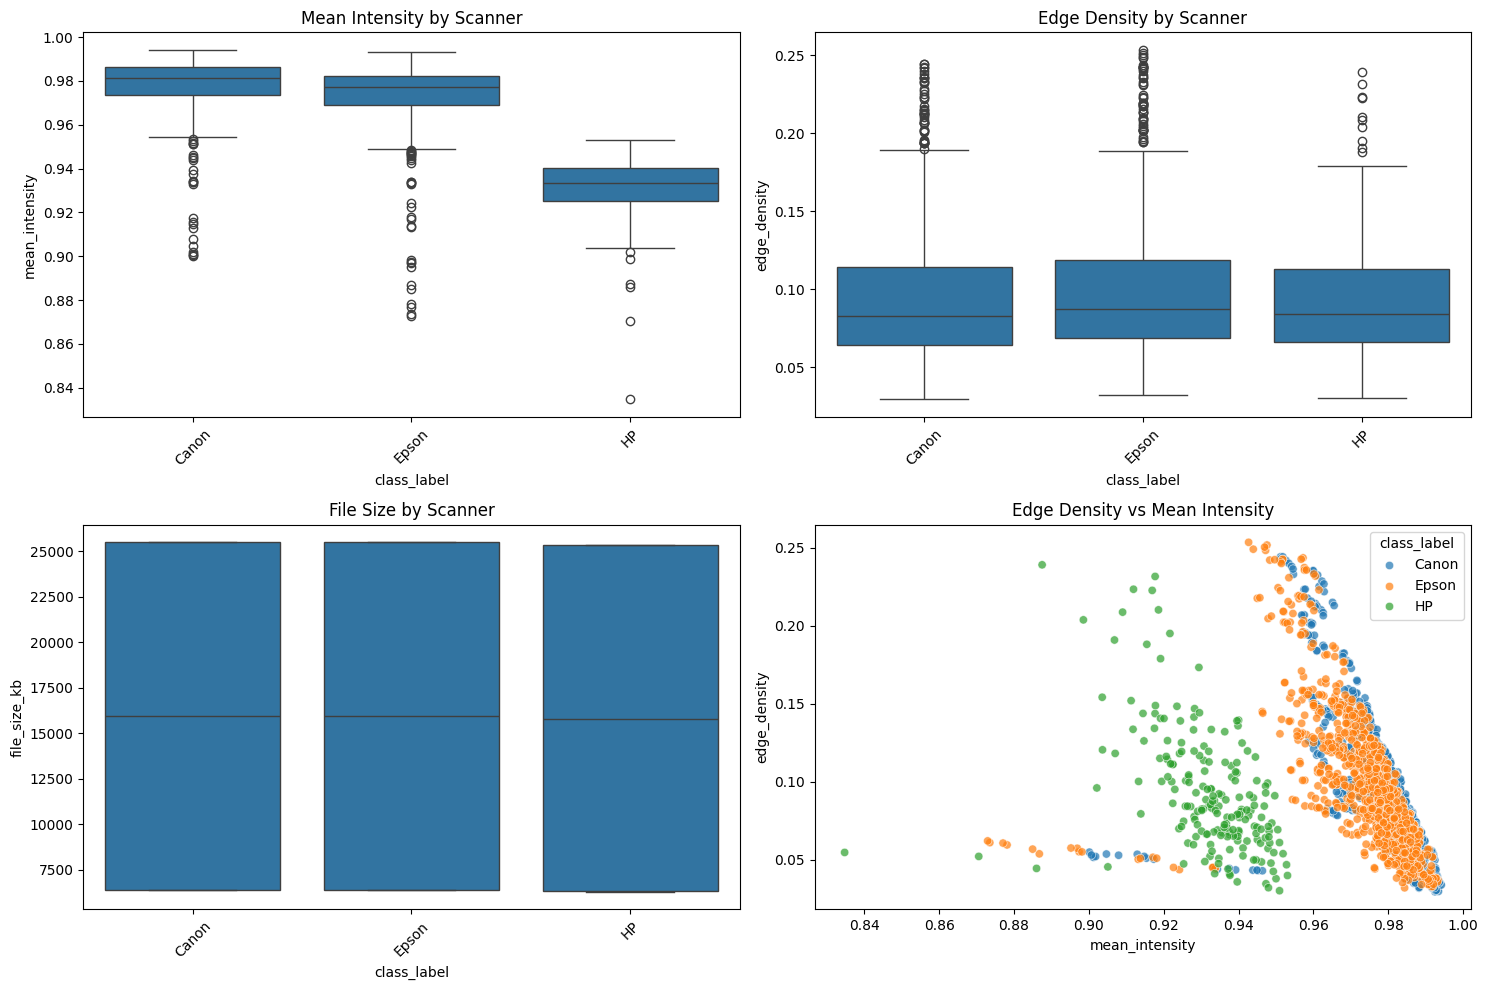

Class distribution:
 - Canon: 1000 samples
 - Epson: 1000 samples
 - HP: 200 samples

🌲 RandomForest accuracy: 0.9705
⚙️ SVM accuracy: 0.8023

✅ Models saved to ./models/

🔍 File: s1_1.tif
Actual Scanner: Canon
Predicted Scanner: Canon


In [8]:
# Change the path to your dataset root
root_dir = r"E:/TraceFinder/Dataset"

# Define scanner name normalization (optional)
known_scanners = {'canon': 'Canon', 'hp': 'HP', 'epson': 'Epson'}

# 1️⃣ Extract features for all images
metadata = process_dataset_root(
    root_path=root_dir,
    known_scanners=known_scanners,
    exts=('.tif', '.tiff'),
    csv_name='all_scanners_features.csv'
)

print(f"\n✅ Extracted {len(metadata)} feature rows from {root_dir}")

# 2️⃣ Visualize distributions
visualize_feature_distributions(metadata)

# 3️⃣ Train models
rf, svm, le, scaler, feature_cols = train_models(metadata)

# 4️⃣ Predict one sample
example_row = metadata.iloc[0]
pred = predict_from_row(example_row, rf, le, feature_cols)
print(f"\n🔍 File: {example_row['file_name']}")
print(f"Actual Scanner: {example_row['class_label']}")
print(f"Predicted Scanner: {pred}")


In [9]:
# 1) Process the full dataset root and save a combined CSV
root_dir = r"E:\TraceFinder\Dataset"

# Optional: normalize common scanner name substrings to canonical labels
# This dictionary maps parts of folder names to a clean 'class_label'
known_scanners = {'canon': 'Canon', 'hp': 'HP', 'epson': 'Epson'}


# The 'process_dataset_root' function is already defined in the notebook.
# It handles dataframe creation, recursion, and saving automatically.
# We just need to call it with the correct parameters.
metadata = process_dataset_root(
    root_path=root_dir,
    known_scanners=known_scanners,
    exts=('.tif', '.tiff'),  # Only process TIFF files
    csv_name='complete_dataset_features.csv' # Save results to this CSV
)

print("\nDataset Summary:")
print("-" * 50)
# Group by scanner and resolution (parent folder name)
summary = metadata.groupby('class_label').agg({
    'file_name': 'count',
    'file_size_kb': ['mean', 'std'],
    'mean_intensity': 'mean',
    'edge_density': 'mean'
}).round(2)

print("\nFiles processed per scanner:")
print(summary)

📂 Found 2200 files under E:\TraceFinder\Dataset
Processed 100/2200 files in 5.4s
Processed 200/2200 files in 20.5s
Processed 300/2200 files in 25.9s
Processed 400/2200 files in 40.8s
Processed 500/2200 files in 46.1s
Processed 600/2200 files in 61.1s
Processed 700/2200 files in 66.5s
Processed 800/2200 files in 82.2s
Processed 900/2200 files in 87.8s
Processed 1000/2200 files in 103.7s
Processed 1100/2200 files in 109.5s
Processed 1200/2200 files in 124.9s
Processed 1300/2200 files in 130.8s
Processed 1400/2200 files in 146.1s
Processed 1500/2200 files in 151.6s
Processed 1600/2200 files in 168.5s
Processed 1700/2200 files in 174.4s
Processed 1800/2200 files in 191.4s
Processed 1900/2200 files in 196.7s
Processed 2000/2200 files in 211.8s
Processed 2100/2200 files in 217.1s
Processed 2200/2200 files in 232.0s
✅ Saved metadata CSV -> E:\TraceFinder\Dataset\complete_dataset_features.csv

Dataset Summary:
--------------------------------------------------

Files processed per scanner:
   